In [1]:
import logistic_adaptive as la
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.special as sc

In [2]:
def get_ab(fr):

    # Get a,b for beta cdf to compute lambda
    # fr < 0.5 needs a=1, b>a, from b=1 to b=top
    # b=top when fr = 0
    # b=1 when fr = 0.5
    # Linear relationship:   (0,top) -- (0.5,1) --> b= int(top - 2*(top-1)*fr)
    
    # fr > 0.5 needs a>b, b=1, from a=1 to a=10
    # a=1 when fr = 0.5
    # a=top when fr = 1
    # Linear relationship: (0.5, 1) -- (1, top) --> a = int(2*(top-1)*fr - top + 2)
    top1 = 5
    top2 = 15
    if fr < 0.5:
        a = 1
        b = int(top2 - 2*(top2-1)*fr)
    else:
        a = int(2*(top1-1)*fr - top1 + 2)
        b = 1
    return a, b

def getlambda(p00, M):
    a, b = get_ab(p00)
    xx = [i/(M+1) for i in range(1, M+1)]
    lambda_ = [sc.betainc(a, b, x) for x in xx]
    return xx, lambda_


def solve_logistic_system(p_0, t_0, t_1, k, r):
    """
    Logistic Growth equation is deterministic
    We give the solution vector betweeen x_start and x_end.
    That is we give [P(x_start), P(x_end)] solution for the system:

    dP/dt = rP(1-P/k)
    P(x_start) = p_0

    The solution is

    p(t) = kp_0e^{r(t-t_0)}/(k + p_0(e^{r(t-t_0)} - 1))
    We give the vector p(t_0), p(t_1) containing 100 values.
    """
    result = (k*p_0*math.exp(r*(t_1-t_0)))/(k + p_0*(math.exp(r*(t_1-t_0)) - 1)) 
    return result

def chop(x, a, b):
    # Energy store function
    if x < a:
        return a
    elif x>=a and x<=b:
        return x
    elif x > b:
        return b

def dynamic_programming_clark(T, M, c, xc, beta, alpha, lambda_, Y, x_0):
    """
    Example from Clark:

    # System Parameters

    T = 20 # Iterations
    M = 3 # Number of patches
    c = 10 # Maximum energy
    xc = 3 # Minimum energy for survival

    # Patch parameters

    beta = [0, 0.004, 0.02] # Patch probability of predation
    alpha = [1, 1, 1] # Patch foraging cost
    lambda_ = [0, 0.4, 0.6] # Patch probability of finding food
    Y = [0, 3, 5] # Increment in the state variable given that food is found 

    # Initial energy level

    x_0 = 4
    """

    v = [0]*M # Store the patches survival probabilities on each iteration
    d = [0]*c #  Store the optimal patch index
    f0 = [0]*c # Survival probability state
    f1 = [0]*xc + [1]*(c-xc) # Final survival proabilities
    fall = [] # Matrix to store all variable states
    dall = [] # Matrix to store all patch selections\
        
    for tt in range(T - 1, 0, -1): # Times loop
    
        # print("t: ", tt, " ========>")
    
        for x in range(xc, c): # Energy loop
    
            # print("x: " , x+1, " Starting with f0= ", f0, "and f1= ", f1)
    
            for j in range(M): # Patches loop
    
                # Evaluate survival probability for each patch
                v[j] = (1-beta[j])*(
                    lambda_[j] * f1[chop(x - alpha[j] + Y[j], xc - 1, c - 1)] + 
                    (1-lambda_[j]) * f1[chop(x-alpha[j], xc - 1, c - 1)]
                )
    
            # v = [round(vv, 10) for vv in v]
            # print(v)
    
            #  Get the maximum survival probability 
            # value for each energy level x
            vm = np.max(v)
    
            # Store the maximum survival probability 
            # value for each energy level x
            f0[x] = vm # round(vm, 10)
    
            # Get the patch that maximizes survival, 
            # the optimal decision at time t, or each energy level x
            d[x] = v.index(vm) + 1
    
        fall = fall + [f0.copy()] # Store the vector with the maximum 
        # survival probabilities at time t in the matrix fall
        dall = dall + [d.copy()] # Store the vector with the optimal
        # patch deicision at time t in the matrix dall
    
        # Update the survival probabilities
        f1 = f0.copy()
    
    fopt = np.transpose(np.array([ff[xc:] for ff in fall])).tolist()
    dopt = np.transpose(np.array([dd[xc:] for dd in dall])).tolist()

    x_vector = [x_0] # State variable

    fopttraj = [] # Variable state
    dopttraj = [] # Optimal patch index

    t = 0

    if xc <= x_0 and x_0 <= c:

        while t < T - 1:

            fopttraj = fopttraj + [fopt[x_vector[-1] - xc - 1][T - 2 - t]]
            dopttraj = dopttraj + [dopt[x_vector[-1] - xc - 1][T - 2 - t]]

            x_vector.append(
                chop(x_vector[-1] - alpha[dopttraj[-1] - 1] + Y[dopttraj[-1] - 1],
                     xc, c))

            t = t + 1

    return x_vector, fopttraj, dopttraj


def find_params_1(M, p0, k, ft_cost, ft_prob_find_food, v_dig):

    alpha = [int(ft_cost*i) + 1 for i in range(1, M+1)]
    # Patch (Foraging Time) foraging cost, depends on foraging time

    lambda_ = [round(chop(ft_prob_find_food*i*(k/p0), 0, 1), 4) for i in range(1, M+1)] # Using linear relationship (as before)
    # _, lambda_ = getlambda(p0/k, M) # Using 'activation function'
    # Patch (Foraging Time) probability of finding food. Decreasing in p, increasing in foraging time.

    Y = [int(v_dig*i)+1 for i in range(0, 2*M, 2)]
        
    return alpha, lambda_, Y


def find_energy_dynamic(t, p_0, k, energy_start, params):
    """
    Implements dynamic programming method to find the
    optimal energy and foraging time decision for each day.
    Depends on the current population density and parameters for each foraging time
    option.
    """

    # Call dynamic_programming_clark with appropiate parameters
    # Obtain the second energy level from this iteration

    # System Parameters

    T = params['T']
    M = params['M']
    c = params['c']
    xc = params['xc']
    ft_cost = params['ft_cost'] # cost of foraging
    ft_prob_find_food = params['ft_prob_find_food'] # gain food from foraging
    v_dig = params['v_dig'] # Velocity of digestion

    # Patch (Foraging Time) probability of predation
    beta = [0]*M
    
    alpha, lambda_, Y = find_params_1(M, p_0, k, ft_cost, # cost of foraging
                  ft_prob_find_food,  # gain food from foraging
                  v_dig # Velocity of digestion
                  )

    alphaUse = params.get('alpha', alpha)
    YUse = params.get('Y', Y)

    print(f"t={t}. lambda={lambda_}")
    # print("p0 to use:", p_0, ". Parameters to use:", alphaUse, beta, lambda_, YUse, ". x0: ",energy_start)

    x_vector, _, dopttraj = dynamic_programming_clark(T, M, c, xc,
                                                      beta, alphaUse, lambda_, YUse,
                                                      x_0=energy_start)
    if len(x_vector) > 1:
        final_energy_day = x_vector[1]
        final_foraging_day = dopttraj[0]
    else:
        final_energy_day = energy_start
        final_foraging_day = 0

    # print(f"Energy at day {t+1}: {final_energy_day}")
    # print("------------")

    return final_energy_day, final_foraging_day, alphaUse, YUse


def adaptive_logistic(p_0, k, t_max, e_start, r_c, params, **kwargs):
    """
    Resolve logistic equation each day
    Update the r parameter daily by computing the
    decided energy to spend this day (this energy is obtained using a
    dynamic programming approach based on Clark and Mangel
    Dynamic Programming in Behavioral Ecology).
    """

    # Decide wether to use classical model or adaptive
    adaptive = kwargs.get('adaptive', True)
    fixed_energy = kwargs.get('fixed_energy', True)
    p_vector = [p_0]

    energy_day = e_start # Initialize with max energy
    r_day = r_c*energy_day

    energy_vector, r_vector, foraging_vector = [], [], []
    alphaUse, YUse = [], []

    for t in range(t_max):

        # Solve the logistic for one day.
        p_range_day = solve_logistic_system(p_vector[-1], t, t+1, k, r_day)

        if adaptive:

            energy_use_for_compute = e_start
            if not fixed_energy:
                energy_use_for_compute = energy_day

            # Obtain new energy consumption for this day using dynamic programming
            energy_day, foraging_day, alphaUse, YUse = find_energy_dynamic(
                t, p_vector[-1], k, energy_use_for_compute, params)

            # Change the growth rate using this new energy.
            r_day = r_c*energy_day

            # Append energy, growth rate and foraging time to vector.
            energy_vector.append(energy_day)
            r_vector.append(r_day)
            foraging_vector.append(foraging_day)

        # Append solution for this day.
        p_vector.append(p_range_day)

    # Return all results
    return p_vector, energy_vector, r_vector, foraging_vector, alphaUse, YUse

def get_plot(k, e_start, p_0, t_max, T, M, c, xc, ft_cost, r_c, alpha, Y, ft_prob_find_food, v_dig, **kwargs):

    useAlphaY = kwargs.get('useAlphaY', False)
    fixed_energy = kwargs.get('fixed_energy', False)

    params = { 'T': T, 'M': M, 'c': c, 'xc': xc, 'ft_cost': ft_cost, 
          'ft_prob_find_food': ft_prob_find_food, 'v_dig': v_dig}

    if useAlphaY:
        params['alpha'] = alpha
        params['Y'] = Y
    
    p_vector, energy_vector, r_vector, foraging_vector, alphaUse, YUse = adaptive_logistic(p_0, k, t_max, e_start, r_c, params, fixed_energy=fixed_energy)
    p_vector0, energy_vector0, r_vector0, foraging_vector0, alphaUse0, YUse0 = adaptive_logistic(p_0, k, t_max, e_start, r_c, params, adaptive=False)
    
    fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(10,3))
    
    # Adaptive
    axs[0].plot(range(len(p_vector)), p_vector, linewidth=3, label='adaptive', color='blue')
    axs[0].plot(range(len(p_vector0)), p_vector0, linewidth=3, label='classic', color='black')
    axs[0].set_title(f'probfindfood = {ft_prob_find_food}', fontsize=8)
    axs[0].legend(prop={'size': 6})
    
    # Energy levels change:
    axs[1].plot(range(len(energy_vector)), energy_vector, linewidth=3, color='red')
    axs[1].set_title('Energy level', fontsize=8)
    axs[1].set_ylim([1, c+1])
    axs[1].axhline(y=xc,xmin=0,xmax=t_max,c="blue",linewidth=0.5,zorder=0)
    axs[1].axhline(y=c,xmin=0,xmax=t_max,c="blue",linewidth=0.5,zorder=0)
    
    axs[2].plot(range(len(foraging_vector)), foraging_vector, linewidth=3, color='green')
    axs[2].set_title('Foraging time', fontsize=8)
    axs[2].set_ylim([0, M+1])
    axs[2].axhline(y=1,xmin=0,xmax=t_max,c="blue",linewidth=0.5,zorder=0)
    axs[2].axhline(y=M,xmin=0,xmax=t_max,c="blue",linewidth=0.5,zorder=0)

    uvector = [YUse[i] - alphaUse[i] for i in range(len(YUse))]
    axs[3].plot(range(len(uvector)), uvector, linewidth=3, color='gray')
    axs[3].set_title('Utility (Y-a)', fontsize=8)
    print(uvector)
    
    plt.subplots_adjust(left=0.1,
                    bottom=0.05,
                    right=0.9, 
                    top=1.5, 
                    wspace=0.4,
                    hspace=0.4)

    fig.suptitle(f"M={M}, T={T}, Estart={e_start}, Emin={xc}, Emax={c}, pff={ft_prob_find_food}, \n A={alphaUse}, Y={YUse}. Fixed energy={fixed_energy}")
    plt.tight_layout()
    alphaUse = [str(a) for a in alphaUse]
    YUse = [str(y) for y in YUse]
    plt.savefig(f'./plots/fig_{fixed_energy}_{M}_{T}_{e_start}_{xc}_{c}_{ft_prob_find_food}__{"a".join(alphaUse)}__{"y".join(YUse)}.png')
    plt.show()

    return p_vector, energy_vector, foraging_vector

# Experiments

t=0. lambda=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
t=1. lambda=[0.0923, 0.1845, 0.2768, 0.369, 0.4613, 0.5535, 0.6458, 0.738, 0.8303, 0.9225]
t=2. lambda=[0.0859, 0.1719, 0.2578, 0.3437, 0.4296, 0.5156, 0.6015, 0.6874, 0.7734, 0.8593]
t=3. lambda=[0.0808, 0.1616, 0.2424, 0.3232, 0.404, 0.4848, 0.5656, 0.6464, 0.7272, 0.808]
t=4. lambda=[0.0747, 0.1494, 0.2241, 0.2988, 0.3735, 0.4482, 0.5229, 0.5976, 0.6723, 0.747]
t=5. lambda=[0.0697, 0.1395, 0.2092, 0.2789, 0.3486, 0.4184, 0.4881, 0.5578, 0.6276, 0.6973]
t=6. lambda=[0.0657, 0.1314, 0.1971, 0.2628, 0.3285, 0.3941, 0.4598, 0.5255, 0.5912, 0.6569]
t=7. lambda=[0.0609, 0.1218, 0.1827, 0.2436, 0.3045, 0.3654, 0.4263, 0.4872, 0.5481, 0.609]
t=8. lambda=[0.057, 0.114, 0.171, 0.2279, 0.2849, 0.3419, 0.3989, 0.4559, 0.5129, 0.5698]
t=9. lambda=[0.0538, 0.1076, 0.1614, 0.2152, 0.269, 0.3228, 0.3767, 0.4305, 0.4843, 0.5381]
t=10. lambda=[0.05, 0.1001, 0.1501, 0.2001, 0.2502, 0.3002, 0.3503, 0.4003, 0.4503, 0.5004]
t=11. lambda=[0.04

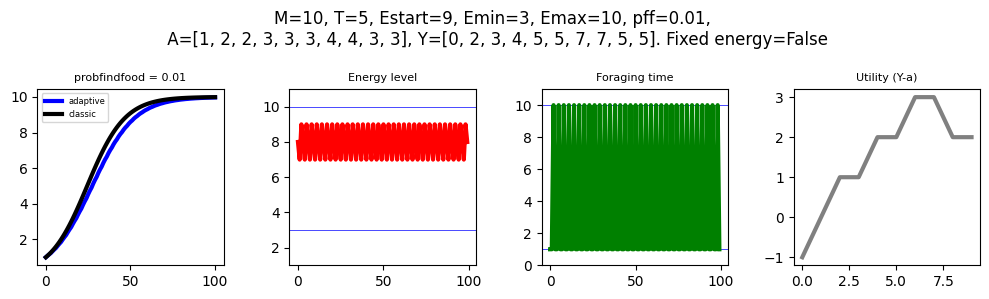

In [7]:
# One plot:
k, e_start, p_0, t_max = 10, 9, 1, 100
# Dynamic programming params
T, M, c, xc = 5, 10, 10, 3
# Iterations, Number of foraging time options, Maximum energy, Minimum energy for survival
ft_cost = 1 # cost of foraging
count = 0
r_c = 0.01
r = r_c*e_start

# Specific:
u = [-1, 0, 1, 1, 2, 2, 3, 3, 2, 2]
alpha = [1, 2, 2, 3, 3, 3, 4, 4, 3, 3]
# u = Y - alpha ===> Y = u + alpha
Y = [u[i] + alpha[i] for i in range(len(u))]
# plt.plot(u, '-b', label="Utility (Y-alpha)")
# plt.show()
# print(alpha)
# print(Y)

ft_prob_find_food = 0.01 # gain food from foraging
v_dig = 1 # Velocity of digestion

p_vector, energy_vector, foraging_vector = get_plot(k, e_start, p_0, t_max, T, M, c, xc, 
                                                    ft_cost, r_c, alpha, Y, ft_prob_find_food, v_dig, 
                                                    fixed_energy=False, useAlphaY=True)

In [ ]:
# k, e_start, p_0, t_max = 10, 7, 1, 50
# # Dynamic programming params
# T, M, c, xc = 10, 5, 10, 3
# # Iterations, Number of foraging time options, Maximum energy, Minimum energy for survival
# ft_cost = 1 # cost of foraging
# count = 0
# r_c = 0.01
        
# r = r_c*e_start
# # print(f'Starting r: {r}')

# limit = 1/(k*M)
# probscheck = np.linspace(0.001, limit, 10).tolist() + np.linspace(limit*1.01, 0.5, 10).tolist()

# # Plot ------>
# title = f"plot_{M}_{T}_{e_start}_{r_c}"
# fig, axs = plt.subplots(int(len(probscheck)/2), 6, figsize=(10,15))
# rowidx = 0

# for idx, prob in enumerate(probscheck):

#     ft_prob_find_food = round(prob,4) # gain food from foraging
#     v_dig = 1 # Velocity of digestion
#     params = { 'T': T, 'M': M, 'c': c, 'xc': xc, 'ft_cost': ft_cost, 
#               'ft_prob_find_food': ft_prob_find_food, 'v_dig': v_dig
#     }

#     # print(f"1/(k*M) = {limit} > {ft_prob_find_food}: {limit>ft_prob_find_food}")
    
#     p_vector, energy_vector, r_vector, foraging_vector = adaptive_logistic(p_0, k, t_max, e_start, r_c, params)
#     p_vector0, energy_vector0, r_vector0, foraging_vector0 = adaptive_logistic(p_0, k, t_max, e_start, r_c, params, adaptive=False)

#     if idx < 10:
#         idxuse = idx
#         id1, id2, id3 = 0, 1, 2
#     else:
#         idxuse = idx - 10
#         id1, id2, id3 = 3, 4, 5

#     # Adaptive
#     axs[idxuse, id1].plot(range(len(p_vector)), p_vector, linewidth=3, label='adaptive', color='blue')
#     axs[idxuse, id1].plot(range(len(p_vector0)), p_vector0, linewidth=3, label='classic', color='black')
#     axs[idxuse, id1].set_title(f'probfindfood = {ft_prob_find_food}', fontsize=8)
#     axs[idxuse, id1].legend(prop={'size': 6})
    
#     # Energy levels change:
#     axs[idxuse, id2].plot(range(len(energy_vector)), energy_vector, linewidth=3, color='red')
#     axs[idxuse, id2].set_title('Energy level', fontsize=8)
#     axs[idxuse, id2].set_ylim([1, c+1])
#     axs[idxuse, id2].axhline(y=xc,xmin=0,xmax=t_max,c="blue",linewidth=0.5,zorder=0)
#     axs[idxuse, id2].axhline(y=c,xmin=0,xmax=t_max,c="blue",linewidth=0.5,zorder=0)

#     axs[idxuse, id3].plot(range(len(foraging_vector)), foraging_vector, linewidth=3, color='green')
#     axs[idxuse, id3].set_title('Foraging time', fontsize=8)
#     axs[idxuse, id3].set_ylim([0, M+1])
#     axs[idxuse, id3].axhline(y=1,xmin=0,xmax=t_max,c="blue",linewidth=0.5,zorder=0)
#     axs[idxuse, id3].axhline(y=M,xmin=0,xmax=t_max,c="blue",linewidth=0.5,zorder=0)
    
# plt.subplots_adjust(left=0.1,
#                     bottom=0.05, 
#                     right=0.9, 
#                     top=1.5, 
#                     wspace=0.4,
#                     hspace=0.4)

# fig.suptitle(title.replace("_", " "), fontsize=10)
# plt.tight_layout()
# fig.savefig(f'./python_plots2/{title}.png')   # save the figure to file
# plt.close(fig)    # close the figure window
# # print(energy_vector[0])
# # print("ft_prob_find_food=", ft_prob_find_food, ", r= ", r_c, ", M= ", M, ", T= ", T, ", c= ",  c, ", xc= ", xc, ", estart= ", e_start, ".")
# # plt.show()
# count = count + 1
# print(count)

###### Dynamic Programming Example from Clark

Average patch selection: 2.3684210526315788
[0.8240357784636516, 0.9094029110685189, 0.9165883612903569, 0.9238298132885499, 0.931130134102, 0.938485627786, 0.94591863604, 0.9533761489, 0.9608850999999999, 0.9684261999999999, 0.9759673, 0.984529, 0.9919, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


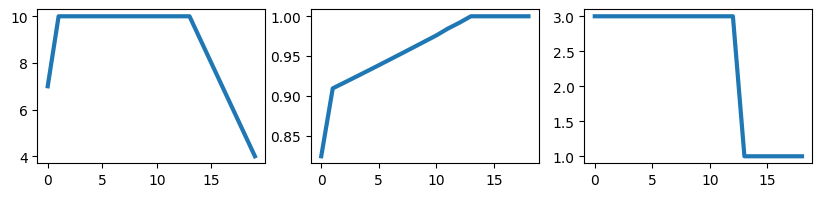

In [279]:
# System Parameters

T = 20 # Iterations
c = 10 # Maximum energy
xc = 3 # Minimum energy for survival

# Patch parameters

M = 3 # Number of patches
# beta = [0, 0.004, 0.02] # Patch probability of predation
# lambda_ = [0, 0.4, 0.6] # Patch probability of finding food. Decreasing in p, increasing in ft.
# alpha = [1, 1, 1] # Patch foraging cost
# Y = [0, 3, 5] # Increment in the state variable given that food is found 
x_0 = 7 # Initial energy level

# M = 5 # Number of patches
beta = [0, 0, 0] # Patch probability of predation
lambda_ = [0.16, 0.27, 0.7] # Patch probability of finding food.
alpha = [1, 2, 2] # Patch foraging cost
Y = [0, 3, 5] # Increment in the state variable given that food is found

x_vector, fopttraj, dopttraj = dynamic_programming_clark(T, M, c, xc, beta, alpha, lambda_, Y, x_0)
fig, axs = plt.subplots(1, 3, figsize=(10,2))
axs[0].plot(range(len(x_vector)), x_vector, linewidth=3)
axs[1].plot(range(len(fopttraj)), fopttraj, linewidth=3)
axs[2].plot(range(len(dopttraj)), dopttraj, linewidth=3)
print(f'Average patch selection: {np.mean(dopttraj)}')
print(fopttraj)
plt.show()

In [261]:
# # Another example
# M = 5
# T = 10 # Iterations
# c = 10 # Maximum energy
# xc = 3 # Minimum energy for survival
# beta = [0, 0, 0, 0, 0] # Patch probability of predation = 0
# alpha = [2, 3, 4, 5, 1] # energy loss
# Y = [1, 3, 5, 7, 9] # energy gain
# x_0 = 7
# ft_prob_find_food = 0.001
# for p in np.linspace(0.01, 0.99, 10):
#     pp = round(p, 4)
#     # _, lambda_ = getlambda(p00=pp, M=M)
#     lambda_ = [round(chop(ft_prob_find_food*i*(1-pp), 0, 1), 4) for i in range(1, M+1)] # Using linear relationship
#     # lambda_ = [1-pp]*M
#     x_vector, fopttraj, dopttraj = dynamic_programming_clark(T, M, c, xc, beta, alpha, lambda_, Y, x_0)
#     fig, axs = plt.subplots(1, 3, figsize=(10,2))
#     axs[0].plot(range(len(x_vector)), x_vector, linewidth=3)
#     axs[1].plot(range(len(fopttraj)), fopttraj, linewidth=3)
#     axs[2].plot(range(len(dopttraj)), dopttraj, linewidth=3)
#     print(f'{pp}: E={x_vector[1]}, ft={dopttraj[1]}')
#     print("lambda: ", lambda_)
#     print(fopttraj)
#     print(dopttraj)
#     print(x_vector)
#     plt.show()

In [168]:
# T = 20 # Iterations
# c = 10 # Maximum energy
# xc = 3 # Minimum energy for survival
# M = 5
# beta = [0, 0, 0, 0, 0] # Patch probability of predation
# alpha = [2, 3, 4, 5, 6]
# lambda_ = [0.0974, 0.1949, 0.2923, 0.3897, 0.4871]
# Y = [1, 3, 5, 7, 9]
# x_0 = 7

M = 3 # Number of patches
beta = [0, 0.004, 0.02] # Patch probability of predation
alpha = [1, 1, 1] # Patch foraging cost
lambda_ = [0, 0.4, 0.6] # Patch probability of finding food. Decreasing in p, increasing in ft.
Y = [0, 3, 5] # Increment in the state variable given that food is found 
x_0 = 4 # Initial energy level

v = [0]*M # Store the patches survival probabilities on each iteration
d = [0]*c #  Store the optimal patch index
f0 = [0]*c # Survival probability state
f1 = [0]*xc + [1]*(c-xc) # Final survival proabilities
fall = [] # Matrix to store all variable states
dall = [] # Matrix to store all patch selections\
    
for tt in range(T - 1, 0, -1): # Times loop

    # print("t: ", tt, " ========>")

    for x in range(xc, c): # Energy loop

        # print("x: " , x+1, " Starting with f0= ", f0, "and f1= ", f1)

        for j in range(M): # Patches loop

            # Evaluate survival probability for each patch
            v[j] = (1-beta[j])*(
                lambda_[j] * f1[chop(x - alpha[j] + Y[j], xc - 1, c - 1)] + 
                (1-lambda_[j]) * f1[chop(x-alpha[j], xc - 1, c - 1)]
            )

        v = [round(vv, 10) for vv in v]
        # print(v)

        #  Get the maximum survival probability 
        # value for each energy level x
        vm = np.max(v)

        # Store the maximum survival probability 
        # value for each energy level x
        f0[x] = round(vm, 10)

        # Get the patch that maximizes survival, 
        # the optimal decision at time t, or each energy level x
        d[x] = v.index(vm) + 1

    fall = fall + [f0.copy()] # Store the vector with the maximum 
    # survival probabilities at time t in the matrix fall
    dall = dall + [d.copy()] # Store the vector with the optimal
    # patch deicision at time t in the matrix dall

    # Update the survival probabilities
    f1 = f0.copy()

fopt = np.transpose(np.array([ff[xc:] for ff in fall])).tolist()
dopt = np.transpose(np.array([dd[xc:] for dd in dall])).tolist()

In [173]:
# np.array([ff[xc:] for ff in fall]).tolist()

In [175]:
x_vector = [x_0] # State variable
    
fopttraj = [] # Variable state
dopttraj = [] # Optimal patch index

t = 0

if xc <= x_0 and x_0 <= c:

    while t < T - 1:

        # print(f"Ah: {x_vector[-1] - xc - 1}")

        val1 = fopt[x_vector[-1] - xc - 1][T - 2 - t]
        val2 = dopt[x_vector[-1] - xc - 1][T - 2 - t]
        # print(f"t={t}, v1 = {val1}, v2 = {val2}")
            
        fopttraj = fopttraj + [val1]
        dopttraj = dopttraj + [val2]

        # print(f"vals use= {x_vector[-1]}, {dopttraj[-1] - 1} | {alpha[dopttraj[-1] - 1]}, {Y[dopttraj[-1] - 1]}")

        valappend = chop(x_vector[-1] - alpha[dopttraj[-1] - 1] + Y[dopttraj[-1] - 1],
                 xc, c)
        # print("vappend=", valappend)

        x_vector.append(valappend)

        t = t + 1

x_vector

[4, 8, 10, 9, 10, 9, 10, 9, 10, 9, 10, 9, 10, 10, 9, 8, 7, 6, 5, 4]